# Is graph position useful for predictive feature selection?

For each NAFLD study, train logistic regression to predict the NAFLD outcome
(binarized: baseline/lowest label value vs. any higher value -- recovers the
existing 0/1 disease-vs-healthy label as-is for the Class A studies, and
splits "no/minimal disease" vs. "any severity" for the Class B ordinal-severity
studies) under three feature-selection regimes:

1. **Full variable set** -- every metabolite measured in that study (mapped +
   UNMAPPED, nothing dropped).
2. **Random k-subset** -- `k` randomly chosen metabolites from that same full
   set, repeated `n` times, to build a null distribution of what k features
   can achieve by chance alone.
3. **Graph-informed k-subset** -- the study's own `k` metabolites *closest*
   (core-graph `posonly` distance) to metabolites found significantly
   associated with the NAFLD outcome in *other* studies (BH-FDR q<0.05 on
   their own univariate Kendall-tau result, direction-agnostic -- a metabolite
   that's negatively associated in one study can still prioritize a
   positively-associated neighbor here). Graph-informed selection can only
   draw from this study's core-graph-mappable metabolites (a metabolite has
   to be a graph node to have a graph distance in the first place), so it's
   naturally a subset of (1)/(2)'s pool, not a separate universe.

Question: does (3) beat the (2) null distribution -- i.e. is a metabolite's
*position in the correlation network relative to other studies' hits* useful
information for picking predictive features, above and beyond picking k
metabolites at random?

In [1]:
import sys
import glob
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.stats.multitest import multipletests

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

from utils.path import find_root

ROOT = find_root()
sys.path.insert(0, str(ROOT / "src"))

from mwnetwork import config
from mwnetwork.correlate import load_combined_study
from mwnetwork.download import get_subject_metadata
from mwnetwork.nafld_labels import LABEL_SPECS

CORE_GRAPH_DIR = ROOT / "checkpoints" / "metabolomics_workbench" / "core_graph"
NAFLD_ANALYSIS_DIR = config.NAFLD_ANALYSIS_DIR
STUDIES_DIR = config.STUDIES_DIR

K_FEATURES = 10       # k in "random k-subset" / "graph-informed top-k"
N_RANDOM = 200         # number of random k-subset repeats per study
N_SPLITS = 5           # CV folds (reduced automatically if the smaller class is < N_SPLITS)
Q_THRESHOLD = 0.05     # BH-FDR threshold for "associated in another study"

rng = np.random.default_rng(0)


In [2]:
D_full = pd.read_csv(CORE_GRAPH_DIR / "graph_distances_posonly.csv", index_col=0)
print("core graph (posonly) nodes:", D_full.shape[0])

study_files = sorted(glob.glob(str(NAFLD_ANALYSIS_DIR / "*.csv")))
study_specs = [tuple(Path(f).stem.split("_", 1)) for f in study_files]  # (study_id, label_name)
print(len(study_specs), "study/label pair(s):", study_specs)


core graph (posonly) nodes: 4429
9 study/label pair(s): [('ST000916', 'nafld_severity'), ('ST000977', 'nafld_vs_healthy'), ('ST001710', 'nafld_severity'), ('ST001711', 'nafld_severity'), ('ST001842', 'nafld_vs_healthy'), ('ST001843', 'nafld_vs_healthy'), ('ST001964', 'nafld_severity'), ('ST002091', 'nafld_vs_healthy'), ('ST002269', 'nafld_vs_healthy')]


## Cross-study "associated metabolite" sets

For every study, BH-FDR-correct its own univariate Kendall-tau result
(already computed in `nafld_analysis/`) and keep the metabolites significant
at `q<0.05`, regardless of the sign of tau. When study X is the prediction
target, the union of every *other* study's significant set is what graph
distance is measured against.

In [3]:
def load_study_hits(study_id, label_name, q_threshold=Q_THRESHOLD):
    path = NAFLD_ANALYSIS_DIR / f"{study_id}_{label_name}.csv"
    df = pd.read_csv(path).dropna(subset=["p_value"])
    q_values = multipletests(df["p_value"], method="fdr_bh")[1]
    return set(df.loc[q_values < q_threshold, "refmet_id"])


hits_by_study = {study_id: load_study_hits(study_id, label_name) for study_id, label_name in study_specs}
for study_id, hits in hits_by_study.items():
    print(f"{study_id}: {len(hits)} metabolite(s) significant at q<{Q_THRESHOLD}")


ST000916: 91 metabolite(s) significant at q<0.05
ST000977: 28 metabolite(s) significant at q<0.05
ST001710: 69 metabolite(s) significant at q<0.05
ST001711: 0 metabolite(s) significant at q<0.05
ST001842: 80 metabolite(s) significant at q<0.05
ST001843: 188 metabolite(s) significant at q<0.05
ST001964: 0 metabolite(s) significant at q<0.05
ST002091: 66 metabolite(s) significant at q<0.05
ST002269: 139 metabolite(s) significant at q<0.05


## Prediction pipeline

In [4]:
def evaluate_auc(X, y, feature_cols, n_splits=N_SPLITS, random_state=0):
    Xs = X[feature_cols]
    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced")),
    ])
    n_splits_eff = min(n_splits, np.bincount(y).min())
    cv = StratifiedKFold(n_splits=n_splits_eff, shuffle=True, random_state=random_state)
    scores = cross_val_score(pipe, Xs, y, scoring="roc_auc", cv=cv)
    return scores.mean()


def load_binary_outcome(study_id, label_name):
    X_full = load_combined_study(STUDIES_DIR / f"{study_id}_combined.csv", drop_unmapped=False)
    X_full.index = X_full.index.astype(str)

    metadata = get_subject_metadata(study_id)
    metadata.index = metadata.index.astype(str)
    label = LABEL_SPECS[study_id][label_name](metadata).reindex(X_full.index)

    y_series = pd.Series(np.nan, index=label.index)
    valid = label.notna()
    y_series[valid] = (label[valid] > label[valid].min()).astype(int)  # baseline vs. any higher label

    samples = y_series.dropna().index.intersection(X_full.index)
    X = X_full.loc[samples].dropna(axis=1, how="all")
    y = y_series.loc[samples].astype(int).values
    return X, y


In [5]:
results = []
random_aucs_by_study = {}

for study_id, label_name in study_specs:
    X, y = load_binary_outcome(study_id, label_name)
    n_samples, n_features_full = X.shape

    full_auc = evaluate_auc(X, y, X.columns)

    K = min(K_FEATURES, n_features_full)
    random_aucs = np.empty(N_RANDOM)
    for i in range(N_RANDOM):
        cols = rng.choice(X.columns, size=K, replace=False)
        random_aucs[i] = evaluate_auc(X, y, cols)
    random_aucs_by_study[study_id] = random_aucs

    candidate_features = [c for c in X.columns if c in D_full.index]
    other_hits = set().union(*(h for sid, h in hits_by_study.items() if sid != study_id))
    other_hits = other_hits & set(D_full.index)

    if candidate_features and other_hits:
        min_dist = D_full.loc[candidate_features, sorted(other_hits)].min(axis=1)
        K_graph = min(K_FEATURES, len(candidate_features))
        graph_topk = min_dist.sort_values().index[:K_graph].tolist()
        graph_auc = evaluate_auc(X, y, graph_topk)
    else:
        graph_topk, graph_auc = [], np.nan

    percentile = float((random_aucs < graph_auc).mean() * 100) if np.isfinite(graph_auc) else np.nan

    results.append({
        "study_id": study_id, "label_name": label_name,
        "n_samples": n_samples, "n_features_full": n_features_full,
        "n_candidate_graph_features": len(candidate_features), "n_other_hits_used": len(other_hits),
        "full_auc": full_auc, "random_mean": random_aucs.mean(), "random_std": random_aucs.std(),
        "graph_auc": graph_auc, "graph_percentile_in_random": percentile,
    })

    print(f"{study_id}: n={n_samples} p={n_features_full}  full_auc={full_auc:.3f}  "
          f"random(k={K})={random_aucs.mean():.3f}+-{random_aucs.std():.3f}  "
          f"graph(k={K_graph if candidate_features and other_hits else 0})={graph_auc:.3f}  "
          f"percentile={percentile:.1f}")

summary = pd.DataFrame(results).set_index("study_id")
summary


ST000916: n=88 p=362  full_auc=0.685  random(k=10)=0.563+-0.086  graph(k=10)=0.676  percentile=91.5


ST000977: n=40 p=74  full_auc=0.962  random(k=10)=0.882+-0.074  graph(k=10)=0.885  percentile=42.5


ST001710: n=517 p=156  full_auc=0.707  random(k=10)=0.633+-0.025  graph(k=10)=0.660  percentile=89.5


ST001711: n=517 p=36  full_auc=0.528  random(k=10)=0.510+-0.023  graph(k=10)=0.519  percentile=66.5


ST001842: n=60 p=149  full_auc=0.928  random(k=10)=0.837+-0.079  graph(k=10)=0.875  percentile=62.5


ST001843: n=60 p=288  full_auc=0.953  random(k=10)=0.871+-0.059  graph(k=10)=0.937  percentile=86.0


ST001964: n=41 p=21  full_auc=0.433  random(k=10)=0.492+-0.075  graph(k=10)=0.543  percentile=73.5


ST002091: n=199 p=701  full_auc=0.764  random(k=10)=0.652+-0.049  graph(k=10)=0.664  percentile=59.0


ST002269: n=165 p=342  full_auc=0.926  random(k=10)=0.771+-0.063  graph(k=10)=0.800  percentile=69.0


,label_name,n_samples,n_features_full,n_candidate_graph_features,n_other_hits_used,full_auc,random_mean,random_std,graph_auc,graph_percentile_in_random
study_id,,,,,,,,,,
ST000916,nafld_severity,88,362,257,441,0.684740,0.563362,0.085826,0.675974,91.5
ST000977,nafld_vs_healthy,40,74,61,471,0.961667,0.881825,0.073782,0.885000,42.5
ST001710,nafld_severity,517,156,135,464,0.707325,0.633066,0.025497,0.660451,89.5
ST001711,nafld_severity,517,36,31,488,0.527913,0.509591,0.023362,0.518579,66.5
ST001842,nafld_vs_healthy,60,149,140,419,0.927679,0.836975,0.078679,0.875000,62.5
ST001843,nafld_vs_healthy,60,288,272,372,0.952679,0.870841,0.058806,0.936607,86.0
ST001964,nafld_severity,41,21,15,488,0.433333,0.491726,0.075205,0.542857,73.5
ST002091,nafld_vs_healthy,199,701,681,433,0.764132,0.652388,0.049398,0.663895,59.0
ST002269,nafld_vs_healthy,165,342,309,421,0.926081,0.770680,0.063209,0.800330,69.0


## Full model vs. random-k baseline vs. graph-informed-k

Boxplots are the random-k null distribution (`n_random` repeats each); the
diamond is the full-variable-set model; the star is the graph-informed
top-k model. If graph position carries real information, the star should sit
above the box (ideally above its whiskers) more often than chance.

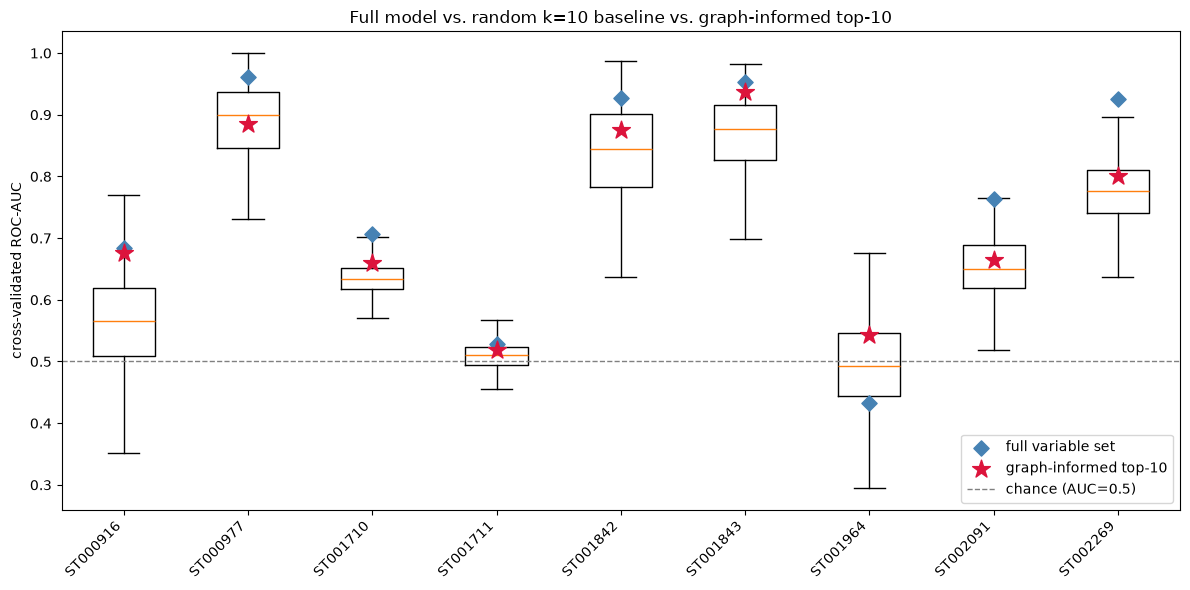

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
positions = np.arange(len(summary))
box_data = [random_aucs_by_study[sid] for sid in summary.index]

ax.boxplot(box_data, positions=positions, widths=0.5, showfliers=False)
ax.scatter(positions, summary["full_auc"], color="steelblue", marker="D", s=60, zorder=3, label="full variable set")
ax.scatter(positions, summary["graph_auc"], color="crimson", marker="*", s=180, zorder=3, label=f"graph-informed top-{K_FEATURES}")
ax.axhline(0.5, color="grey", ls="--", lw=1, label="chance (AUC=0.5)")

ax.set_xticks(positions)
ax.set_xticklabels(summary.index, rotation=45, ha="right")
ax.set_ylabel("cross-validated ROC-AUC")
ax.set_title(f"Full model vs. random k={K_FEATURES} baseline vs. graph-informed top-{K_FEATURES}")
ax.legend()
fig.tight_layout()
plt.show()


## Summary

In [7]:
n_beats_random_mean = (summary["graph_auc"] > summary["random_mean"]).sum()
n_above_90th_pct = (summary["graph_percentile_in_random"] > 90).sum()
n_studies_with_graph_score = summary["graph_auc"].notna().sum()

print(f"studies with a usable graph-informed score: {n_studies_with_graph_score}/{len(summary)}")
print(f"graph-informed AUC > random-k mean: {n_beats_random_mean}/{n_studies_with_graph_score}")
print(f"graph-informed AUC above the 90th percentile of the random-k null: {n_above_90th_pct}/{n_studies_with_graph_score}")

summary[["n_samples", "n_features_full", "n_candidate_graph_features", "n_other_hits_used",
         "full_auc", "random_mean", "random_std", "graph_auc", "graph_percentile_in_random"]]


studies with a usable graph-informed score: 9/9
graph-informed AUC > random-k mean: 9/9
graph-informed AUC above the 90th percentile of the random-k null: 1/9


,n_samples,n_features_full,n_candidate_graph_features,n_other_hits_used,full_auc,random_mean,random_std,graph_auc,graph_percentile_in_random
study_id,,,,,,,,,
ST000916,88,362,257,441,0.684740,0.563362,0.085826,0.675974,91.5
ST000977,40,74,61,471,0.961667,0.881825,0.073782,0.885000,42.5
ST001710,517,156,135,464,0.707325,0.633066,0.025497,0.660451,89.5
ST001711,517,36,31,488,0.527913,0.509591,0.023362,0.518579,66.5
ST001842,60,149,140,419,0.927679,0.836975,0.078679,0.875000,62.5
ST001843,60,288,272,372,0.952679,0.870841,0.058806,0.936607,86.0
ST001964,41,21,15,488,0.433333,0.491726,0.075205,0.542857,73.5
ST002091,199,701,681,433,0.764132,0.652388,0.049398,0.663895,59.0
ST002269,165,342,309,421,0.926081,0.770680,0.063209,0.800330,69.0
